**FOOD DELIVERY ANALYSIS**


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('food_delivery_dataset.csv')
df

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21316,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6568490993,"03:26 AM, January 30 2025",Delivered,Zomato Delivery,5km,1 x Fried Chicken Desi Peri Peri Bites (Bone),...,NaN,NaN,NaN,NaN,NaN,14.32,9.0,Correctly,Wrong item(s) delivered,c6ee80eb35f2ef1630fd93ea88f8c0ac27eff57229a6d5...
21317,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6564842673,"02:44 AM, January 29 2025",Delivered,Zomato Delivery,5km,1 x Fried Chicken 65 Masala Boneless Bites,...,NaN,NaN,NaN,NaN,NaN,NaN,10.8,Missed,NaN,d2a0153ba6512894c1bebe974f6898ba10df50abc2c954...
21318,21523055,Masala Junction,Sector 4,Delhi NCR,6553527557,"10:05 PM, January 24 2025",Delivered,Zomato Delivery,8km,1 x Korean Fried Chicken Slider,...,5.0,Yummy food! Delicious food! Lip smacking food!...,NaN,NaN,NaN,16.27,9.4,Incorrectly,NaN,0b6168cbaf96aa5a0ae6b46d19d83ec9cad0d9508d43d7...
21319,21523055,Masala Junction,Sector 4,Delhi NCR,6541170157,"02:27 PM, January 21 2025",Delivered,Zomato Delivery,9km,1 x Ooh Saucy Fries,...,4.0,The peri peri fries were truly so tasty and de...,NaN,NaN,NaN,12.77,1.3,Correctly,NaN,410b3e056e511e3423d9497c629ca897f91cace2a2a732...


In [6]:
print(df.shape)

(21321, 29)


In [7]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            21321 non-null  object 


In [8]:
df.isnull().sum()

Restaurant ID                                             0
Restaurant name                                           0
Subzone                                                   0
City                                                      0
Order ID                                                  0
Order Placed At                                           0
Order Status                                              0
Delivery                                                  0
Distance                                                  0
Items in order                                            0
Instructions                                          20601
Discount construct                                     5498
Bill subtotal                                             0
Packaging charges                                         0
Restaurant discount (Promo)                               0
Restaurant discount (Flat offs, Freebies & others)        0
Gold discount                           

In [9]:

df['Instructions'] = df['Instructions'].fillna('No Instructions')

df['Discount construct'] = df['Discount construct'].fillna('No Discount')

df['Review'] = df['Review'].fillna('No Review')

df['Cancellation / Rejection reason'] = df['Cancellation / Rejection reason'].fillna('No Cancellation')

df['Customer complaint tag'] = df['Customer complaint tag'].fillna('No Complaint')



df['Rating'] = df['Rating'].fillna(0)

df['Restaurant compensation (Cancellation)'] = df['Restaurant compensation (Cancellation)'].fillna(0)

df['Restaurant penalty (Rejection)'] = df['Restaurant penalty (Rejection)'].fillna(0)

df['KPT duration (minutes)'] = df['KPT duration (minutes)'].fillna(df['KPT duration (minutes)'].median())

df['Rider wait time (minutes)'] = df['Rider wait time (minutes)'].fillna(df['Rider wait time (minutes)'].median())

In [10]:
df.isnull().sum()

Restaurant ID                                         0
Restaurant name                                       0
Subzone                                               0
City                                                  0
Order ID                                              0
Order Placed At                                       0
Order Status                                          0
Delivery                                              0
Distance                                              0
Items in order                                        0
Instructions                                          0
Discount construct                                    0
Bill subtotal                                         0
Packaging charges                                     0
Restaurant discount (Promo)                           0
Restaurant discount (Flat offs, Freebies & others)    0
Gold discount                                         0
Brand pack discount                             

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe() 

,Restaurant ID,Order ID,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes)
count,2.132100e+04,2.132100e+04,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.0,21321.000000,21321.000000
mean,2.074413e+07,6.354622e+09,750.076838,32.564592,65.091816,31.795058,0.099128,3.039324,682.616113,0.509029,2.223276,0.0,17.319083,4.811477
std,2.447193e+05,1.230263e+08,498.759428,22.235898,85.401604,131.487091,3.264261,17.070780,465.313977,1.456636,38.132717,0.0,6.240865,4.965264
min,2.032061e+07,6.086767e+09,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.500000,0.000000,0.000000,0.0,0.000000,0.100000
25%,2.063570e+07,6.250751e+09,459.000000,18.450000,0.000000,0.000000,0.000000,0.000000,387.450000,0.000000,0.000000,0.0,13.430000,1.000000
50%,2.065987e+07,6.357715e+09,629.000000,28.450000,80.000000,0.000000,0.000000,0.000000,597.450000,0.000000,0.000000,0.0,16.330000,3.100000
75%,2.088265e+07,6.456827e+09,899.000000,39.950000,100.000000,0.000000,0.000000,0.000000,837.900000,0.000000,0.000000,0.0,19.980000,7.400000
max,2.152306e+07,6.573392e+09,16080.000000,603.000000,4020.000000,7787.000000,280.100000,554.800000,12663.000000,5.000000,3236.980000,0.0,90.870000,73.800000


In [13]:
df['Order Status'].value_counts()

Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64

In [14]:
df['City'].value_counts()

City
Delhi NCR    21321
Name: count, dtype: int64

In [15]:
df['Restaurant name'].value_counts()

Restaurant name
Aura Pizzas             14548
Swaad                    6332
Dilli Burger Adda         227
Tandoori Junction         154
The Chicken Junction       32
Masala Junction            28
Name: count, dtype: int64

In [16]:
df['Total'].sum()

14554058.139999999

In [17]:
df['Total'].mean()

682.6161127526851

In [18]:
df['Rating'].value_counts()

Rating
0.0    18830
5.0     1728
4.0      360
1.0      177
3.0      144
2.0       82
Name: count, dtype: int64

In [19]:
df['Restaurant discount (Promo)'].value_counts()

Restaurant discount (Promo)
0.00      10262
100.00     2791
90.00      1177
80.00      1048
99.00       971
          ...  
242.40        1
83.06         1
113.81        1
226.20        1
274.50        1
Name: count, Length: 700, dtype: int64

In [20]:
df['Distance'].value_counts()

Distance
2km     3558
1km     3346
3km     3212
4km     2410
5km     2140
6km     2112
7km     1282
9km      767
8km      709
<1km     649
10km     384
11km     253
12km     115
16km      87
14km      82
15km      77
13km      63
17km      26
18km      25
19km      19
20km       3
21km       2
Name: count, dtype: int64

In [21]:
df['KPT duration (minutes)'].mean()

17.31908306364617

In [22]:
df['Rider wait time (minutes)'].mean()

4.811476947610338

In [23]:
df['Cancellation / Rejection reason'].value_counts()

Cancellation / Rejection reason
No Cancellation          21135
Cancelled by Customer       89
Cancelled by Zomato         81
Merchant device issue       12
Kitchen is full              3
Items out of stock           1
Name: count, dtype: int64

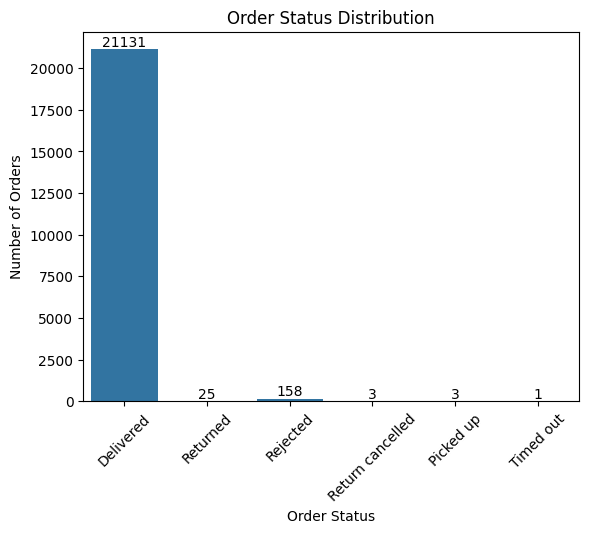

In [24]:
a=sns.countplot(x='Order Status', data=df)
for container in a.containers:
    a.bar_label(container)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

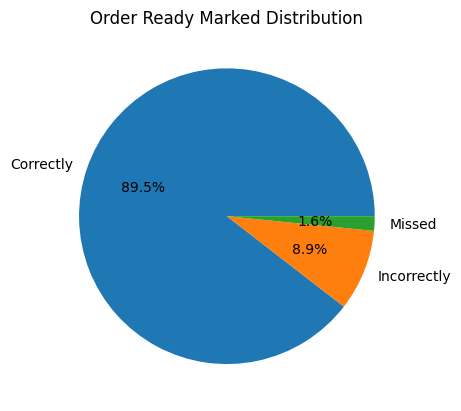

In [25]:
ready_status = df['Order Ready Marked'].value_counts()
plt.pie(ready_status,labels=ready_status.index,autopct='%1.1f%%')
plt.title("Order Ready Marked Distribution")
plt.show()

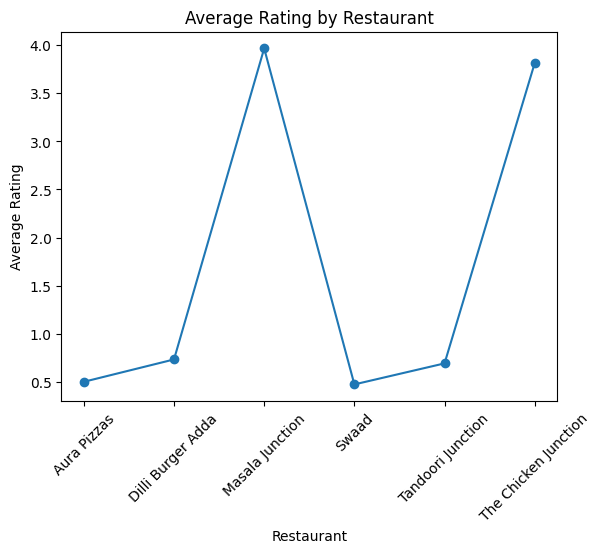

In [26]:
restaurant_rating = df.groupby('Restaurant name')['Rating'].mean()

plt.plot(restaurant_rating.index,restaurant_rating.values,marker='o')
plt.title("Average Rating by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

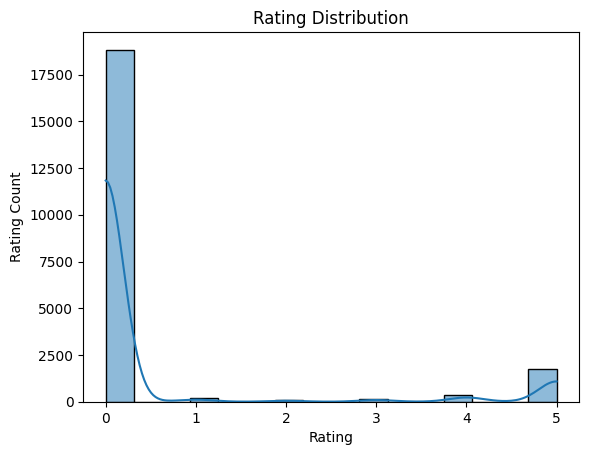

In [33]:
sns.histplot(df['Rating'], kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Rating Count")

plt.show()

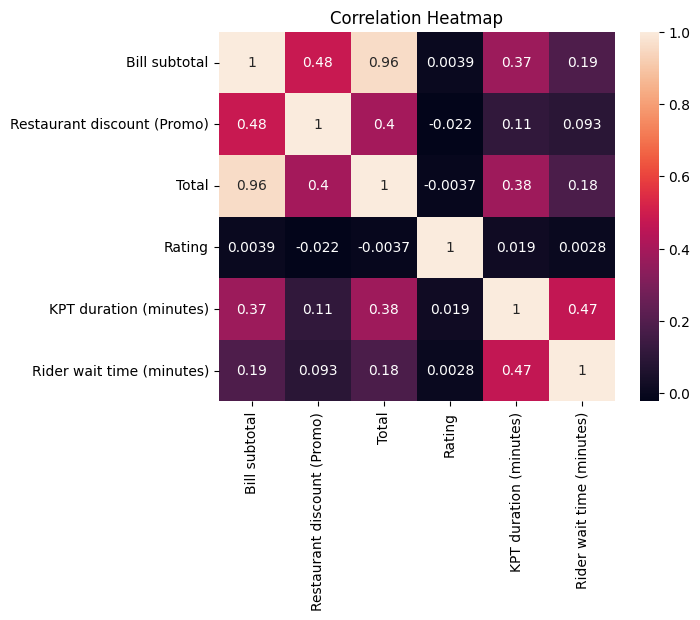

In [30]:

sns.heatmap(df[['Bill subtotal','Restaurant discount (Promo)','Total','Rating','KPT duration (minutes)','Rider wait time (minutes)']].corr(),annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Insights: #

- Most orders were successfully delivered, indicating a high order fulfillment rate and efficient delivery operations.

- Aura Pizzas received the highest number of orders, making it the most popular restaurant in the dataset.

- Customer ratings were generally positive, with 5-star ratings being the most frequently given rating.

- Most customers ordered from nearby restaurants (1–6 km), showing a preference for shorter delivery distances.

- The average Kitchen Preparation Time (KPT) and Rider Wait Time were maintained at reasonable levels, supporting smooth delivery performance.

- Order cancellations and rejections were very low compared to the total number of delivered orders, indicating effective order management.

- Promotional discounts and higher bill amounts contributed significantly to revenue generation, helping restaurants attract customers and increase sales.